In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
train = pd.read_csv("/content/train.csv")
sample = pd.read_csv("/content/sample_submission.csv")

In [98]:
train.shape

(774412, 4)

In [99]:
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [100]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774412 entries, 0 to 774411
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    774412 non-null  object
 1   store   774412 non-null  int64 
 2   item    774412 non-null  int64 
 3   sales   774412 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 23.6+ MB


In [101]:
train.isnull().sum()

,0
date,0
store,0
item,0
sales,0


In [102]:
train.describe()

,store,item,sales
count,774412.000000,774412.000000,774412.000000
mean,5.471584,21.708000,52.977021
std,2.875087,12.244357,29.130498
min,1.000000,1.000000,0.000000
25%,3.000000,11.000000,30.000000
50%,5.000000,22.000000,48.000000
75%,8.000000,32.000000,71.000000
max,10.000000,43.000000,231.000000


In [103]:
train.duplicated().sum()

np.int64(0)

In [104]:
train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [105]:
train['date'] = pd.to_datetime(train['date'], errors='coerce')
train['year'] = train['date'].dt.year
train['month'] = train['date'].dt.month
train['week'] = train['date'].dt.isocalendar().week
train['day'] = train['date'].dt.day
train['quarter'] = train['date'].dt.quarter
train['day_of_week'] = train['date'].dt.dayofweek
train['is_weekend'] = train['day_of_week'].isin([5, 6]).astype(int)

In [106]:
train.head(4)

,date,store,item,sales,year,month,week,day,quarter,day_of_week,is_weekend
0,2013-01-01,1,1,13,2013,1,1,1,1,1,0
1,2013-01-02,1,1,11,2013,1,1,2,1,2,0
2,2013-01-03,1,1,14,2013,1,1,3,1,3,0
3,2013-01-04,1,1,13,2013,1,1,4,1,4,0


In [107]:
sale_df = train.groupby('item')['sales'].sum()

In [108]:
train['store'].value_counts()
train['item'].value_counts()
train['year'].value_counts()
train['is_weekend'].value_counts()

,count
is_weekend,
0,553030
1,221382


In [109]:
item_stats = train.groupby('item')['sales'].agg(
    mean='mean',
    std='std',
    median='median',
    min='min',
    max='max'
)

item_stats['CV'] = (
    item_stats['std'] / item_stats['mean']
)

item_stats.sort_values('CV', ascending=False).head(10)

,mean,std,median,min,max,CV
item,,,,,,
5,18.358708,7.265167,18.0,1,50,0.395734
1,21.981599,8.468922,21.0,1,59,0.385273
27,22.049726,8.461641,21.0,1,59,0.383753
41,22.002136,8.402470,21.0,2,60,0.381893
4,22.010241,8.403898,21.0,0,66,0.381818
16,25.656079,9.603270,25.0,2,70,0.374308
34,25.735761,9.617910,25.0,2,79,0.373718
40,29.249398,10.822959,28.0,3,74,0.370023
23,29.297864,10.819549,28.0,3,81,0.369295


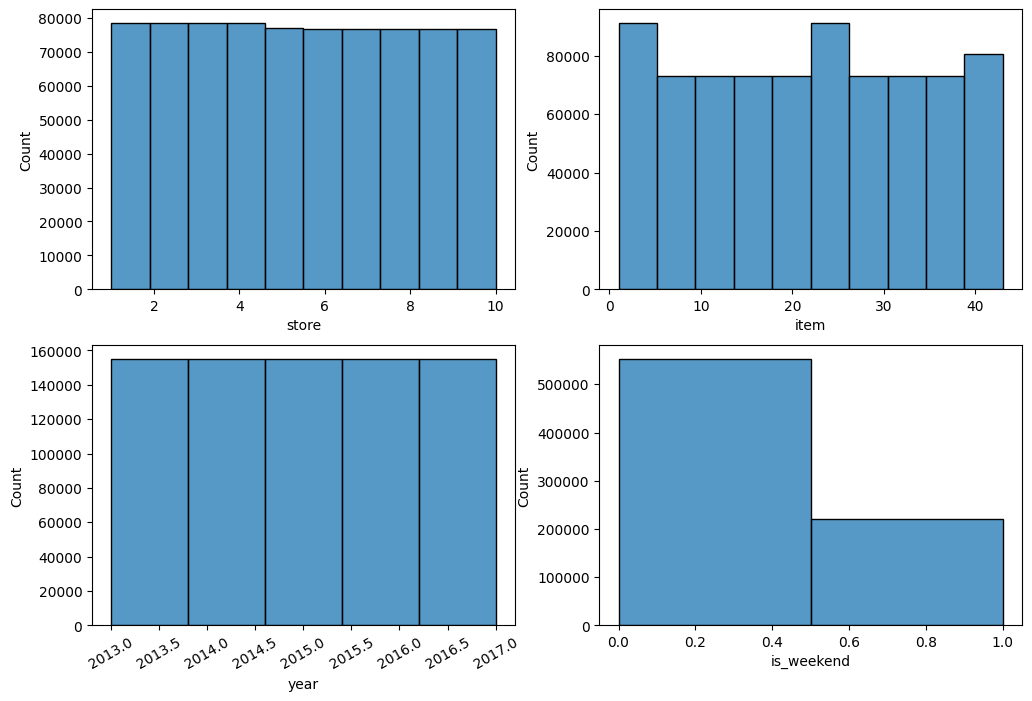

In [110]:
fig,ax=plt.subplots(nrows=2,ncols=2,figsize=(12,8))

sns.histplot(data=train,x='store',bins=10,ax=ax[0,0])
sns.histplot(data=train,x='item',bins=10,ax=ax[0,1])
sns.histplot(data=train,x='year',bins=5,ax=ax[1,0])
ax[1,0].tick_params(axis='x', rotation=30)
sns.histplot(data=train,x='is_weekend',bins=2,ax=ax[1,1])
plt.show()

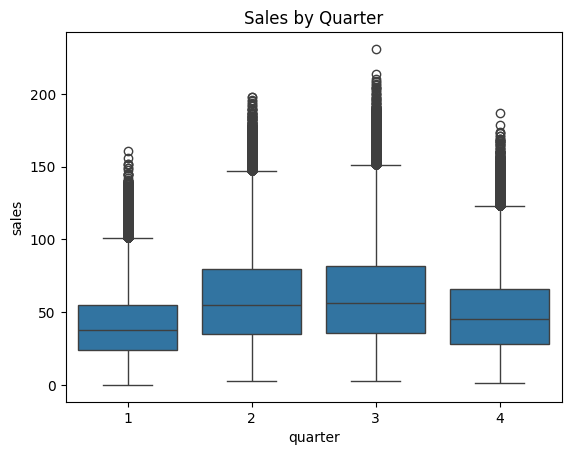

In [111]:
sns.boxplot(data=train,x='quarter',y='sales')
plt.title('Sales by Quarter')
plt.show()

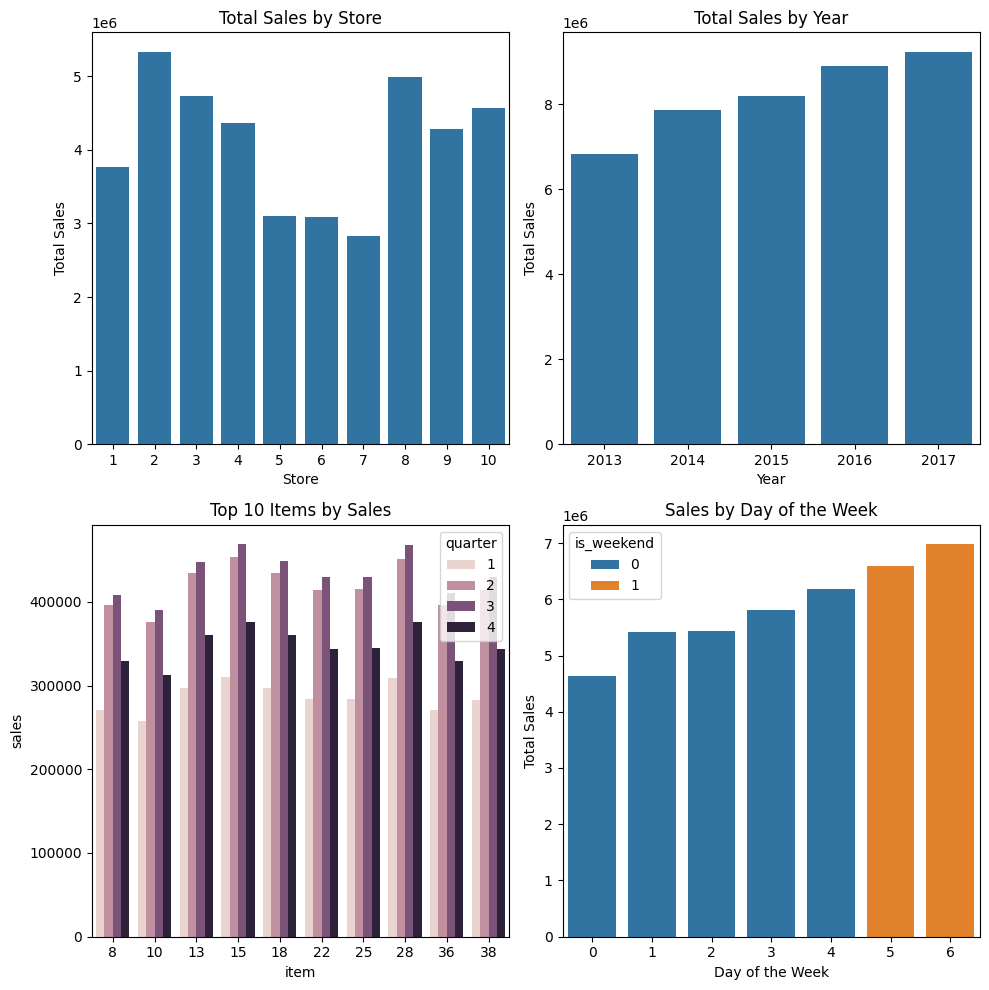

In [112]:
fig, ax = plt.subplots(nrows=2,ncols=2,figsize=(10,10))

st_df = train.groupby('store')['sales'].sum().reset_index()

sns.barplot(data=st_df, x='store', y='sales',ax=ax[0,0])
ax[0,0].set_title('Total Sales by Store')
ax[0,0].set_xlabel('Store')
ax[0,0].set_ylabel('Total Sales')

sl_df = train.groupby('year')['sales'].sum().reset_index()
sns.barplot(data=sl_df,x='year',y='sales',ax=ax[0,1])
ax[0,1].set_title('Total Sales by Year')
ax[0,1].set_xlabel('Year')
ax[0,1].set_ylabel('Total Sales')

it_df = train.groupby(['item','quarter'])['sales'].sum().reset_index()
top_10_items = train.groupby('item')['sales'].sum().nlargest(10).index

top_10_df = it_df[it_df['item'].isin(top_10_items)]

sns.barplot(data=top_10_df, x='item', y='sales', hue='quarter', ax=ax[1,0])

ax[1, 0].set_title('Top 10 Items by Sales')
ax[1, 0].tick_params(axis='x', rotation=0)


wk_df = train.groupby(['day_of_week','is_weekend'])['sales'].sum().reset_index()
sns.barplot(data=wk_df,x='day_of_week',y='sales',hue='is_weekend',ax=ax[1,1])
ax[1,1].set_title('Sales by Day of the Week')
ax[1,1].set_xlabel('Day of the Week')
ax[1,1].set_ylabel('Total Sales')
plt.tight_layout()
plt.show()

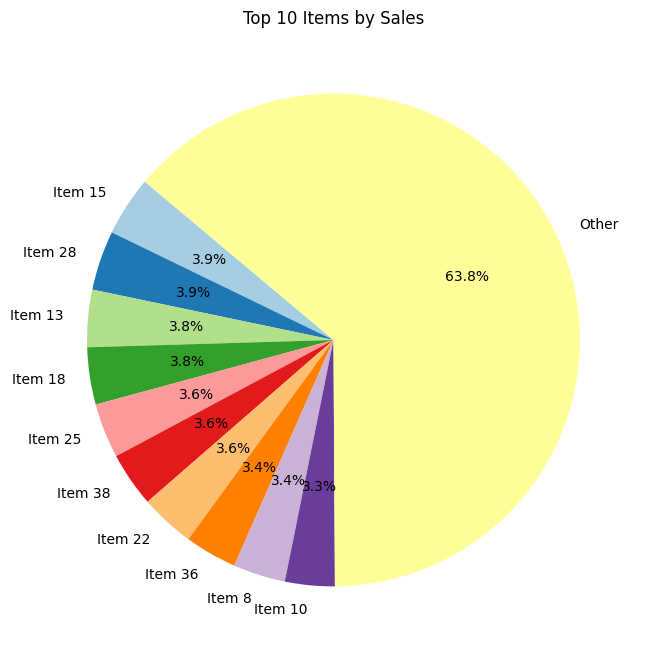

In [113]:
item_sales = train.groupby('item')['sales'].sum().sort_values(ascending=False)
top_10 = item_sales.head(10)
top_10['other'] = item_sales.iloc[10:].sum()
# 4. Plot the Clean Pie Chart
plt.figure(figsize=(10, 8))
plt.pie(top_10,
        labels=[f"Item {idx}" if idx != 'other' else 'Other' for idx in top_10.index],
        autopct='%1.1f%%',startangle=140, colors=plt.cm.Paired.colors)
plt.title('Top 10 Items by Sales')
plt.show()

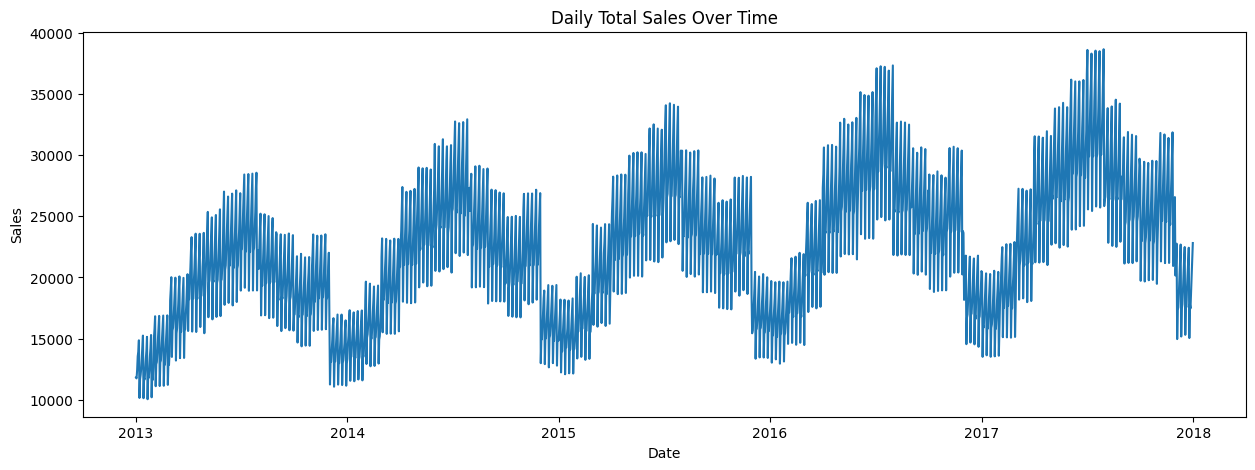

In [114]:
daily_sales = (
    train.groupby('date')['sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(15,5))
plt.plot(
    daily_sales['date'],
    daily_sales['sales']
)

plt.title('Daily Total Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

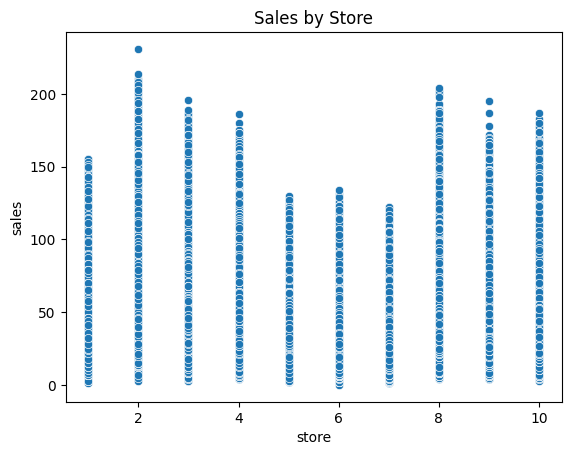

In [115]:
sns.scatterplot(data=train,x='store',y='sales')
plt.title('Sales by Store')
plt.show()

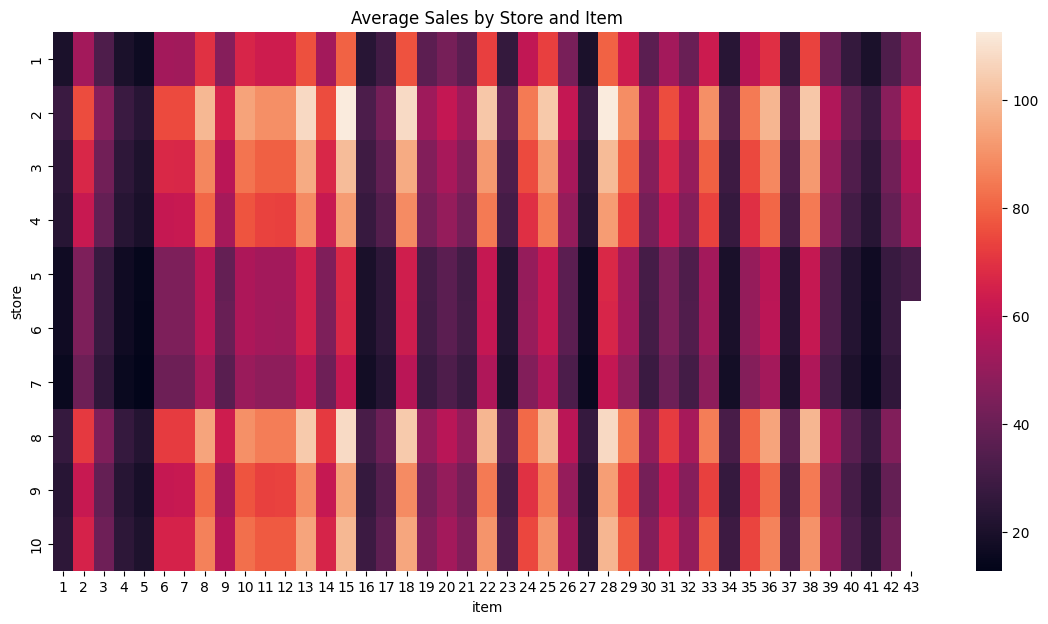

In [116]:
store_item = train.pivot_table(
    index='store',
    columns='item',
    values='sales',
    aggfunc='mean'
)

plt.figure(figsize=(14, 7))
sns.heatmap(store_item)
plt.title('Average Sales by Store and Item')
plt.show()